In [28]:
pwd

'/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Scripts'

In [1]:
# =========================
# System / Utilities
# =========================
import os
import re
import tempfile
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")  # keep notebook output tidy

# =========================
# Data / Plotting
# =========================
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Data Access (optional)
# =========================
try:
    import yfinance as yf
except Exception:
    yf = None

try:
    from pandas_datareader import data as web
except Exception:
    web = None

# =========================
# ML: Models, Metrics, CV
# =========================
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from scipy.stats import pearsonr

# =========================
# Time-Series / Stats
# =========================
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================
# Imbalanced Data (optional)
# =========================
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None

# =========================
# Explainability (optional)
# =========================
try:
    import shap
except Exception:
    shap = None

# =========================
# NLP: FinBERT (optional)
# =========================
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # reduce tokenizer thread warnings
try:
    import torch
    import torch.nn.functional as F
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
except Exception:
    torch = None
    F = None
    AutoModelForSequenceClassification = None
    AutoTokenizer = None

# =========================
# Scraping / PDF (optional)
# =========================
try:
    import requests
except Exception:
    requests = None

try:
    import pdfplumber
except Exception:
    pdfplumber = None

try:
    from bs4 import BeautifulSoup
except Exception:
    BeautifulSoup = None

# =========================
# Notebook display helpers
# =========================
from IPython.display import Markdown, display

In [4]:
# Claim all the folders used
project_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject"
scripts_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Scripts"
macro_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro"
beigebook_directory = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook"
model_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Models"
results_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Results"

## Data Log

---

### 1. Macroeconomic Data Sources (FRED)

All five macroeconomic indicators were downloaded in `.csv` format from the [Federal Reserve Economic Data (FRED)](https://fred.stlouisfed.org/) website and stored in the local `macro` directory.

| #  | Filename           | FRED Series Name       | Description                                     | Source URL | Date Range                   | Freq. | Rows |
|----|--------------------|------------------------|--------------------------------------------------|------------|------------------------------|--------|------|
| 01 | 01_CPIAUCSL.csv    | CPIAUCSL               | Consumer Price Index for All Urban Consumers     | [Link](https://fred.stlouisfed.org/series/CPIAUCSL) | 1947-01-01 → 2025-07-01 | MS | 943 |
| 02 | 02_INDPRO.csv      | INDPRO                 | Industrial Production Index                      | [Link](https://fred.stlouisfed.org/series/INDPRO)   | 1919-01-01 → 2025-07-01 | MS | 1279 |
| 03 | 03_VIXCLS.csv      | VIXCLS                 | CBOE Volatility Index (VIX)                      | [Link](https://fred.stlouisfed.org/series/VIXCLS)   | 1990-01-02 → 2025-08-14 | B  | 9293 |
| 04 | 04_T10YIE.csv      | T10YIE                 | 10-Year Breakeven Inflation Rate                 | [Link](https://fred.stlouisfed.org/series/T10YIE)   | 2003-01-02 → 2025-08-15 | B  | 5902 |
| 05 | 05_GS10.csv        | GS10                   | 10-Year Treasury Constant Maturity Rate          | [Link](https://fred.stlouisfed.org/series/GS10)     | 1953-04-01 → 2025-07-01 | MS | 868  |

---

### 2. Market Data Sources (Yahoo Finance)

Market data was downloaded using the `yfinance` Python package and saved to the local `macro` directory.

| #  | Filename           | Yahoo Ticker | Description                                | Source URL | Date Range                   | Freq. | Rows |
|----|--------------------|--------------|--------------------------------------------|------------|------------------------------|--------|------|
| 06 | 06_sp500_raw.csv   | ^GSPC        | S&P 500 Index – represents U.S. equity     | [Link](https://finance.yahoo.com/quote/%5EGSPC/history) | 1927-12-30 → 2025-08-05 | D  | 24514 |
| 07 | 07_tlt_raw.csv     | TLT          | iShares 20+ Year Treasury Bond ETF         | [Link](https://finance.yahoo.com/quote/TLT/history)     | 2002-07-30 → 2025-08-05 | D  | 5792  |

---

### 3. Beige Book Sentiment Source

Beige Book documents were collected and parsed for sentiment extraction. Initial attempts to access the full archive were blocked by reCAPTCHA. Final documents were sourced from the official Federal Reserve website.

| #  | Source                                             | Format        | Coverage        | Access Notes |
|----|----------------------------------------------------|---------------|------------------|---------------|
| 08 | [federalreserve.gov](https://www.federalreserve.gov/monetarypolicy/beige-book-default.htm) | PDF / HTML    | 1996 – Present  | Successfully accessed and parsed |
| 09 | Federal Reserve Bank of Minneapolis (Attempted)   | HTML          | 1970 – Present  | Blocked by reCAPTCHA |

---

### 4. Data Availability and Access Limitations

In the referenced paper, the sample period spans from **January 1988 to March 2021**, with all features originally sourced from **Refinitiv** and the **Global Financial Database (GFD)**.

While I was able to access **Refinitiv (LSEG Workspace)** via the **George Washington University (GWU) library portal**, some specific time series were not available due to **licensing restrictions**.

To ensure **reproducibility** and **open accessibility**, I substituted with **public data sources**:
- **Federal Reserve Economic Data (FRED)** for macroeconomic indicators
- **Yahoo Finance** for market-level pricing data (e.g., S&P 500, TLT)

These replacements provide sufficient **temporal coverage**, **granularity**, and **signal fidelity** to support baseline modeling with minimal trade-offs in quality or interpretability.

## Data Preprocessing Log

Before modeling or analysis, all macroeconomic time series are preprocessed to ensure consistency in frequency, alignment, and analytical usability.

---

### Resampling and Alignment

- **Daily series** (e.g., SP500, TLT, VIX, T10YIE) resampled to **monthly** using `mean` (for indicators) or `last` (for prices).
- **Monthly series** (e.g., CPI, GS10, INDPRO) remain unchanged.
- All timestamps normalized to `YYYY-MM-01`.
- All series reindexed to match CPI’s monthly index.
- Feature window extended back to **1992-01** (11-year history) to support 10-year rolling calculations, even though modeling starts in 2003.

---

## Feature Engineering: Derived Columns

Derived using a 10-year (120-month) rolling window unless otherwise noted.

- `Inflation_10y`: 10-year compound annual growth of CPI.  
- `InflationVol_10y`: 10-year rolling std of 12-month CPI differences.  
- `RealYield_10y`: Nominal 10-year Treasury yield (GS10) minus expected inflation (T10YIE).  
- `INDPRO_YoY`: Year-over-year growth in industrial production index.  
- `RollingCorr_24m`: 24-month forward-looking correlation between S&P 500 and TLT.  

---

## Final Dataset Summary

- Unified monthly frequency across all features.
- Final modeling set spans: **2003-01 to 2023-08** (248 monthly observations).
- Ready for regime classification, feature ranking, and forecasting.

### Data Availability and Access Limitations

In the referenced paper, the sample period spans from **January 1988 to March 2021**, with all features originally sourced from **Refinitiv** and the **Global Financial Database (GFD)**.

While I was able to access **Refinitiv (LSEG Workspace)** via the **George Washington University (GWU) library portal**, some specific time series were not available due to licensing restrictions.

To ensure reproducibility, I proceeded with **publicly accessible alternatives**:
- **Federal Reserve Economic Data (FRED)** from the St. Louis Fed for macroeconomic indicators
- **Yahoo Finance** for market prices (e.g., S&P 500, TLT)

These sources provide sufficient coverage and granularity to support model replication with minimal trade-offs in quality.

## Macroeconomic Data Sources

All five series below were downloaded from the Federal Reserve Economic Data (FRED) website in `.csv` format and are stored locally in the `macro` directory.

| #  | Filename           | FRED Series Name       | Description                                     | Source URL |
|----|--------------------|------------------------|--------------------------------------------------|------------|
| 01 | 01_CPIAUCSL.csv    | CPIAUCSL               | Consumer Price Index for All Urban Consumers     | [Link](https://fred.stlouisfed.org/series/CPIAUCSL) |
| 02 | 02_INDPRO.csv      | INDPRO                 | Industrial Production Index                      | [Link](https://fred.stlouisfed.org/series/INDPRO) |
| 03 | 03_VIXCLS.csv      | VIXCLS                 | CBOE Volatility Index (VIX)                      | [Link](https://fred.stlouisfed.org/series/VIXCLS) |
| 04 | 04_T10YIE.csv      | T10YIE                 | 10-Year Breakeven Inflation Rate                | [Link](https://fred.stlouisfed.org/series/T10YIE) |
| 05 | 05_GS10.csv        | GS10                   | 10-Year Treasury Constant Maturity Rate          | [Link](https://fred.stlouisfed.org/series/GS10) |

In [5]:
# List all files in the directory
file_list = sorted(os.listdir(macro_directory))

# Print them
print("Files in macro_directory:\n")
for filename in file_list:
    print(filename)

Files in macro_directory:

01_CPIAUCSL.csv
02_INDPRO.csv
03_VIXCLS.csv
04_T10YIE.csv
05_GS10.csv
06_sp500.csv
06_sp500_raw.csv
07_tlt.csv
07_tlt_raw.csv


##  Market Data from Yahoo Finance
The following raw market data files were downloaded using the `yfinance` Python package and saved in the local `macro` directory:

| #  | Filename           | Yahoo Ticker | Description                                | Source URL |
|----|--------------------|--------------|--------------------------------------------|------------|
| 06 | 06_sp500_raw.csv   | ^GSPC        | S&P 500 Index – represents U.S. equity     | [Link](https://finance.yahoo.com/quote/%5EGSPC/history) |
| 07 | 07_tlt_raw.csv     | TLT          | iShares 20+ Year Treasury Bond ETF         | [Link](https://finance.yahoo.com/quote/TLT/history) |

In [42]:
# # Set macro directory
# os.makedirs(macro_directory, exist_ok=True)

# # Define tickers and corresponding filenames
# tickers = {
#     "^GSPC": "06_sp500_raw.csv", # S&P 500 Composite Total Return Index
#     "TLT": "07_tlt_raw.csv" # S&P U.S. 10-Year Treasury Bond Total Return Index
# }

# # Download and save data
# for ticker, filename in tickers.items():
#     print(f"\n Downloading {ticker} data from Yahoo Finance...")
#     data = yf.download(ticker, period="max", progress=False)

#     print(f"{ticker} covers: {data.index.min().date()} to {data.index.max().date()}")
#     print(f"Preview:\n{data.head()}")
#     print(f"Preview:\n{data.tail()}")

#     filepath = os.path.join(macro_directory, filename)
#     data.to_csv(filepath)
#     print(f"Saved to: {filepath}")


YF.download() has changed argument auto_adjust default to True
^GSPC covers: 1927-12-30 to 2025-08-05
Preview:
Price           Close       High        Low       Open Volume
Ticker          ^GSPC      ^GSPC      ^GSPC      ^GSPC  ^GSPC
Date                                                         
1927-12-30  17.660000  17.660000  17.660000  17.660000      0
1928-01-03  17.760000  17.760000  17.760000  17.760000      0
1928-01-04  17.719999  17.719999  17.719999  17.719999      0
1928-01-05  17.549999  17.549999  17.549999  17.549999      0
1928-01-06  17.660000  17.660000  17.660000  17.660000      0
Saved to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/06_sp500_raw.csv

TLT covers: 2002-07-30 to 2025-08-05
Preview:
Price           Close       High        Low       Open Volume
Ticker            TLT        TLT        TLT        TLT    TLT
Date                                                         
2002-07-30  37.326050  37.500045  37.326050  37.

In [50]:
# # Convert 06_sp500_raw.csv
# sp500_raw_path = os.path.join(macro_directory, "06_sp500_raw.csv")
# sp500_out_path = os.path.join(macro_directory, "06_sp500.csv")

# sp500 = pd.read_csv(sp500_raw_path, header=[0, 1], index_col=0, parse_dates=True)
# sp500_close = sp500[("Close", "^GSPC")].rename("SP500").reset_index()
# sp500_close.rename(columns={"Date": "observation_date"}, inplace=True)
# sp500_close.to_csv(sp500_out_path, index=False)
# print(f"Saved: {sp500_out_path}")

# # Convert 07_tlt_raw.csv
# tlt_raw_path = os.path.join(macro_directory, "07_tlt_raw.csv")
# tlt_out_path = os.path.join(macro_directory, "07_tlt.csv")

# tlt = pd.read_csv(tlt_raw_path, header=[0, 1], index_col=0, parse_dates=True)
# tlt_close = tlt[("Close", "TLT")].rename("TLT").reset_index()
# tlt_close.rename(columns={"Date": "observation_date"}, inplace=True)
# tlt_close.to_csv(tlt_out_path, index=False)
# print(f"Saved: {tlt_out_path}")

Saved: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/06_sp500.csv
Saved: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/07_tlt.csv


## Load and Normalize Time Series CSVs into a Dictionary of DataFrames

In [170]:
files = {
    'CPI': '01_CPIAUCSL.csv',
    'INDPRO': '02_INDPRO.csv',
    'VIX': '03_VIXCLS.csv',
    'T10YIE': '04_T10YIE.csv',
    'GS10': '05_GS10.csv',
    'SP500': '06_sp500.csv',
    'TLT': '07_tlt.csv'
}

# Load into a dictionary of DataFrames
macro_data = {}
for name, file in files.items():
    df = pd.read_csv(os.path.join(macro_directory, file))
    df.columns = df.columns.str.strip().str.lower()
    df.rename(columns={df.columns[0]: "date"}, inplace=True)
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    macro_data[name] = df

In [172]:
# Inspect Metadata
for name, df in macro_data.items():
    print(f"\n{name}")
    print(df.info())
    print(df.describe())
    print(df.head(3))
    print(df.tail(3))


CPI
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 943 entries, 1947-01-01 to 2025-07-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   cpiaucsl  943 non-null    float64
dtypes: float64(1)
memory usage: 14.7 KB
None
         cpiaucsl
count  943.000000
mean   122.996422
std     88.436150
min     21.480000
25%     32.700000
50%    109.500000
75%    198.950000
max    322.132000
            cpiaucsl
date                
1947-01-01     21.48
1947-02-01     21.62
1947-03-01     22.00
            cpiaucsl
date                
2025-05-01   320.580
2025-06-01   321.500
2025-07-01   322.132

INDPRO
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1279 entries, 1919-01-01 to 2025-07-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   indpro  1279 non-null   float64
dtypes: float64(1)
memory usage: 20.0 KB
None
            indpro
count  1279.000000
mean     4

In [138]:
# Function to inspect each CSV and return stats
def inspect_file(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    df.rename(columns={df.columns[0]: "date"}, inplace=True)
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)

    date_range = (df.index.min().strftime('%Y-%m-%d'), df.index.max().strftime('%Y-%m-%d'))
    row_count = len(df)

    # Try to infer frequency
    inferred_freq = pd.infer_freq(df.index)

    if inferred_freq:
        frequency = inferred_freq
    else:
        # Fallback: use median timedelta to guess
        delta = df.index.to_series().diff().median()
        if pd.Timedelta("1D") - pd.Timedelta("1H") <= delta <= pd.Timedelta("1D") + pd.Timedelta("1H"):
            frequency = "D"
        elif pd.Timedelta("30D") - pd.Timedelta("5D") <= delta <= pd.Timedelta("30D") + pd.Timedelta("5D"):
            frequency = "MS"
        else:
            frequency = "Irregular/Unknown"

    return date_range, frequency, row_count

# Loop through and print results
print("Macro Variable File Summary:\n")
print(f"{'Label':<8} | {'Date Range':<35} | {'Frequency':<18} | {'Rows':>5}")
print("-" * 80)

for label, filename in files.items():
    path = os.path.join(macro_directory, filename)
    date_range, freq, count = inspect_file(path)
    print(f"{label:<8} | From {date_range[0]} to {date_range[1]:<20} | {freq:<18} | {count:>5}")

Macro Variable File Summary:

Label    | Date Range                          | Frequency          |  Rows
--------------------------------------------------------------------------------
CPI      | From 1947-01-01 to 2025-07-01           | MS                 |   943
INDPRO   | From 1919-01-01 to 2025-07-01           | MS                 |  1279
VIX      | From 1990-01-02 to 2025-08-14           | B                  |  9293
T10YIE   | From 2003-01-02 to 2025-08-15           | B                  |  5902
GS10     | From 1953-04-01 to 2025-07-01           | MS                 |   868
SP500    | From 1927-12-30 to 2025-08-05           | D                  | 24514
TLT      | From 2002-07-30 to 2025-08-05           | D                  |  5792


/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/2027177367.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/2027177367.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/2027177367.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/2027177367.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh

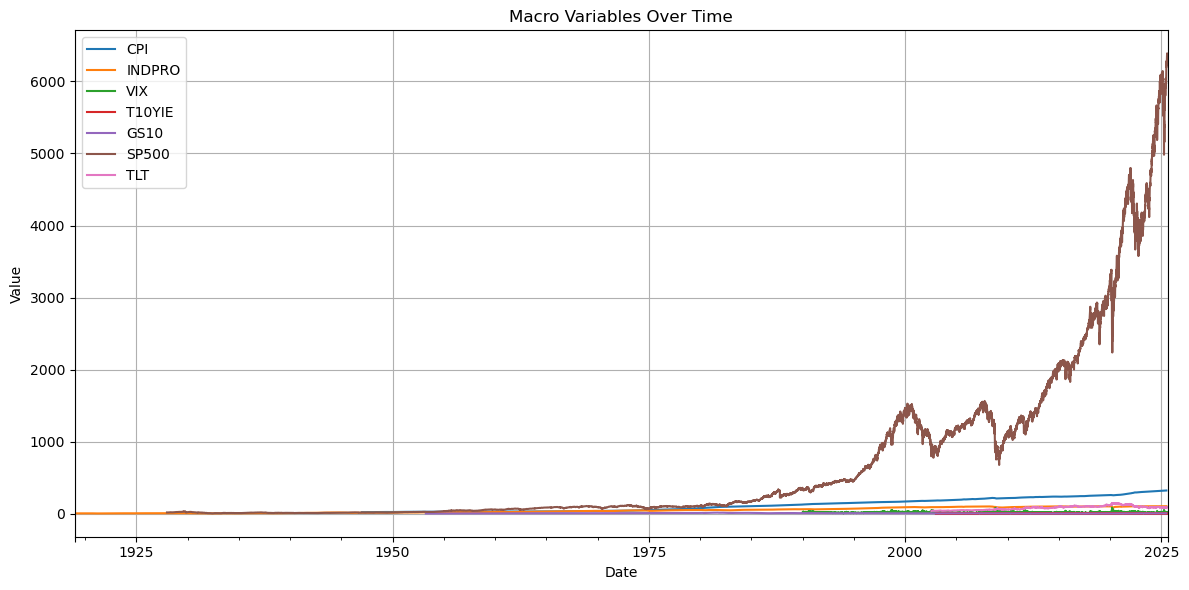

In [140]:
# Visualize Each Time Series
plt.figure(figsize=(12, 6))
for name, df in macro_data.items():
    df.iloc[:, 0].plot(label=name)

plt.legend()
plt.title("Macro Variables Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/329919439.py:5: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/329919439.py:5: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/329919439.py:5: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh3n9h0000gn/T/ipykernel_2377/329919439.py:5: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  df.iloc[:, 0].plot(label=name)
/var/folders/cn/cwwm58h92777zysns3xh3n9h

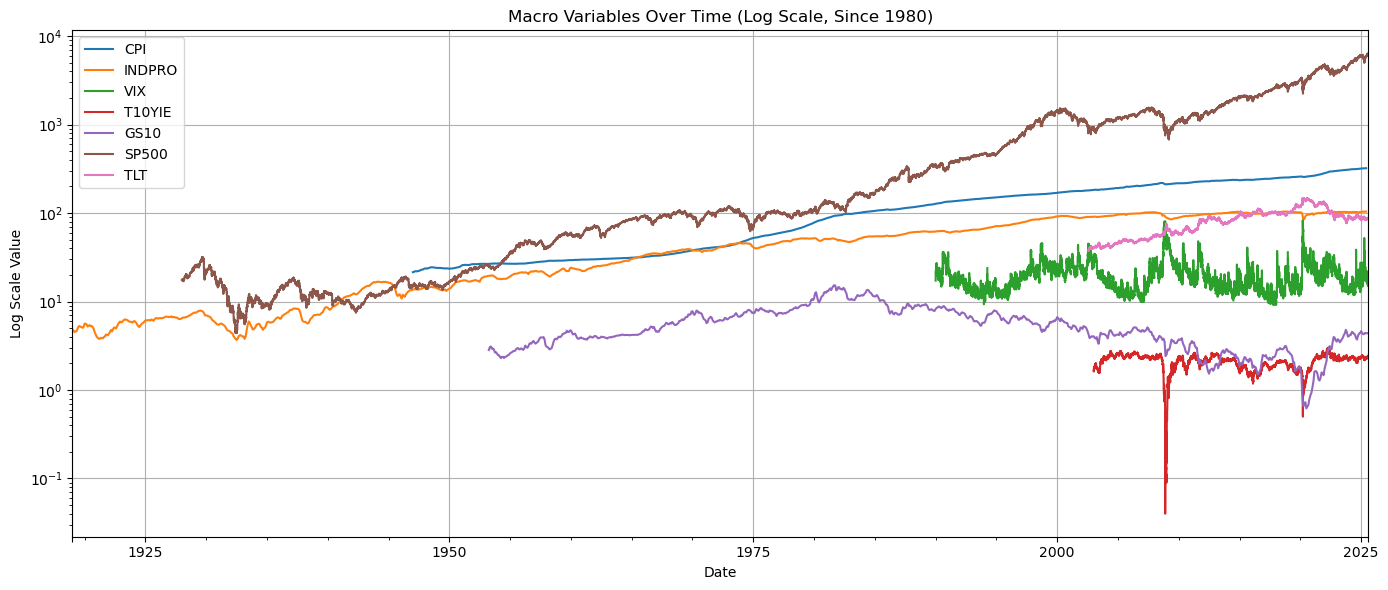

In [17]:
# Apply logarithmic scale as current plot is dominated by the S&P 500
plt.figure(figsize=(14, 6))

for name, df in macro_data.items():
    df.iloc[:, 0].plot(label=name)

plt.yscale('log')
plt.legend()
plt.title("Macro Variables Over Time (Log Scale, Since 1980)")
plt.xlabel("Date")
plt.ylabel("Log Scale Value")
plt.grid(True)
plt.tight_layout()
plt.show()

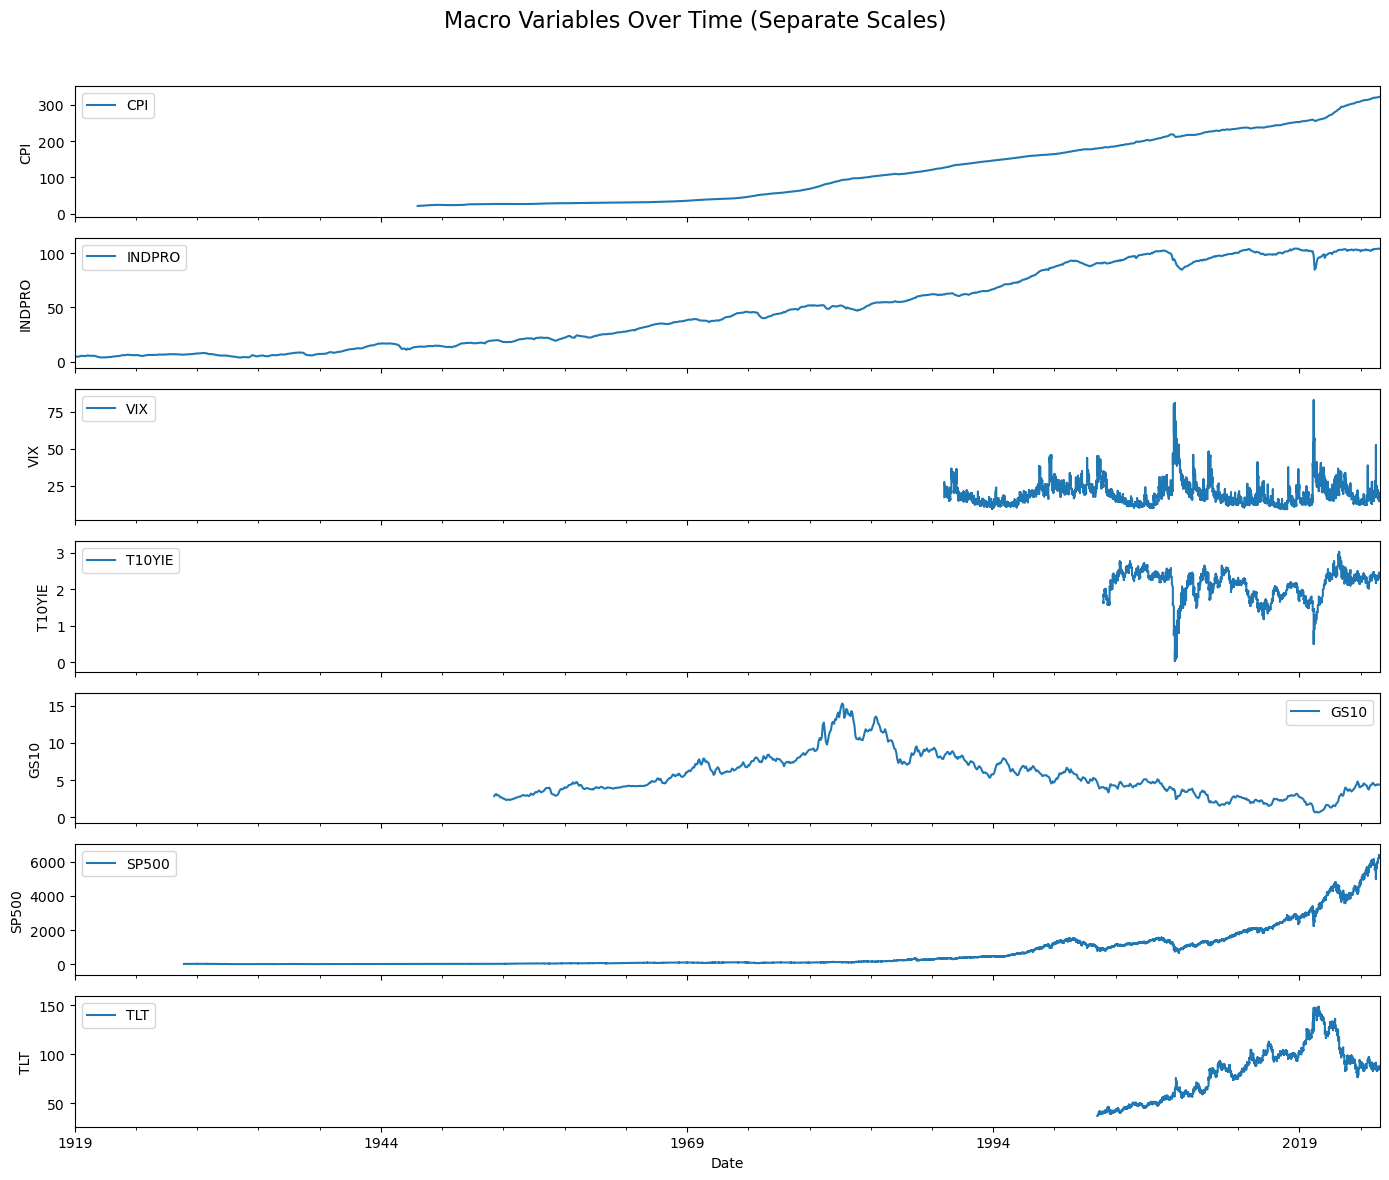

In [354]:
# Create subplots wtih full date range of all macro variables

# Get the earliest date across all macro variables
min_date = min(df.index.min() for df in macro_data.values())

# Create subplots
fig, axs = plt.subplots(len(macro_data), 1, figsize=(14, 12), sharex=True)

# Loop through each macro variable and plot
for ax, (name, df) in zip(axs, macro_data.items()):
    series = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna()
    series.plot(ax=ax, label=name, legend=True)
    ax.set_ylabel(name)

    # Set dynamic Y-axis with 10% padding
    min_val, max_val = series.min(), series.max()
    pad = (max_val - min_val) * 0.1
    ax.set_ylim(min_val - pad, max_val + pad)

    # Set x-axis starting point
    ax.set_xlim(left=min_date)

plt.xlabel("Date")
plt.suptitle("Macro Variables Over Time (Separate Scales)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [144]:
# List each series and its individual start date
start_dates = {name: df.index.min() for name, df in macro_data.items()}
for name, date in start_dates.items():
    print(f"{name}: starts on {date.date()}")

# Find the series with the latest start date
latest_start_series = max(start_dates, key=start_dates.get)
latest_start_date = start_dates[latest_start_series]

print(f"\nLatest common start date is from **{latest_start_series}**: {latest_start_date.date()}")

CPI: starts on 1947-01-01
INDPRO: starts on 1919-01-01
VIX: starts on 1990-01-02
T10YIE: starts on 2003-01-02
GS10: starts on 1953-04-01
SP500: starts on 1927-12-30
TLT: starts on 2002-07-30

Latest common start date is from **T10YIE**: 2003-01-02


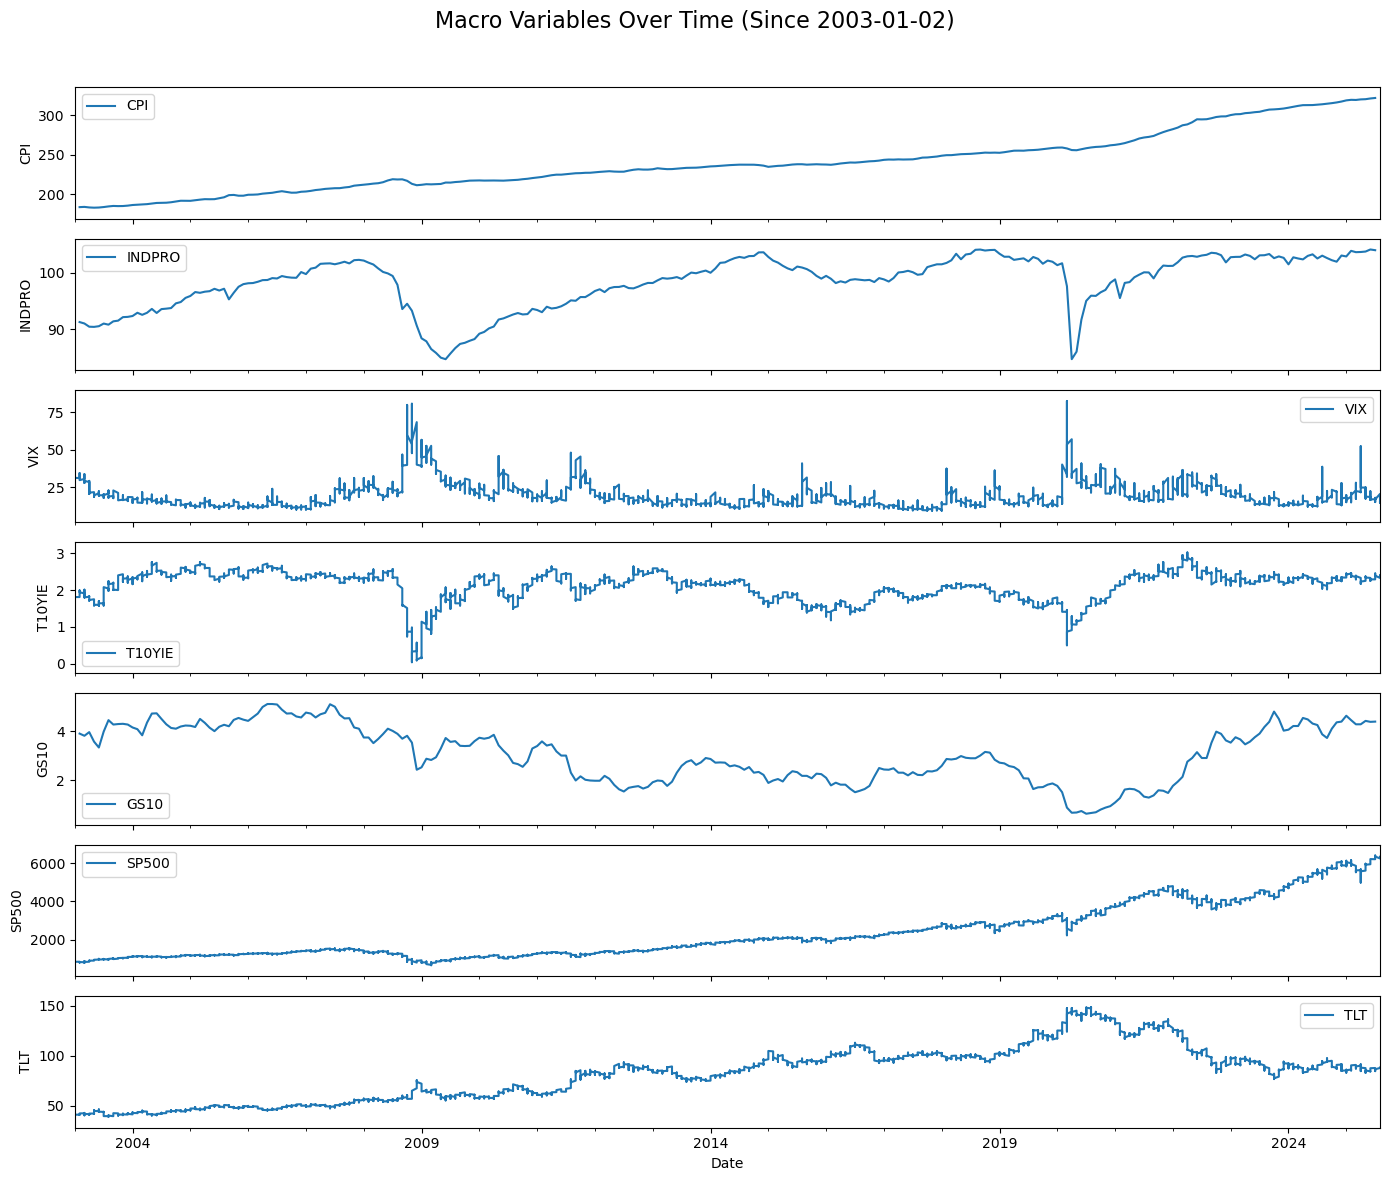

In [146]:
# Create subplots using latest_start_date as X-Axis Limit
fig, axs = plt.subplots(len(macro_data), 1, figsize=(14, 12), sharex=True)

for ax, (name, df) in zip(axs, macro_data.items()):
    series = df.iloc[:, 0]

    # Ensure numeric and clean series
    series = pd.to_numeric(series, errors='coerce').dropna()

    # Filter to start from latest common date
    series = series[series.index >= latest_start_date]

    # Plot the series
    series.plot(ax=ax, label=name, legend=True)

    # Label and dynamic y-axis
    ax.set_ylabel(name)
    min_val, max_val = series.min(), series.max()
    pad = (max_val - min_val) * 0.1
    ax.set_ylim(min_val - pad, max_val + pad)

# Final touches
plt.xlabel("Date")
plt.suptitle(f"Macro Variables Over Time (Since {latest_start_date.date()})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Macro Variables Overview (Starting from 2003)

This notebook summarizes the macroeconomic and market variables used in the analysis.  
Since **T10YIE (10-Year Breakeven Inflation Rate)** has the **earliest available date (2003-01-02)** among the selected daily indicators, all series are aligned starting from **2003** to ensure consistency in the analysis window.

---

### Data Dictionary

| Variable | Description |
|----------|-------------|
| **CPI** | Consumer Price Index – measures the average change over time in the prices paid by urban consumers for a market basket of goods and services. |
| **INDPRO** | Industrial Production Index – tracks the real output of manufacturing, mining, and electric and gas utilities. |
| **VIX** | CBOE Volatility Index – a popular measure of the stock market's expectation of volatility implied by S&P 500 index options. Often called the “fear gauge.” |
| **T10YIE** | 10-Year Breakeven Inflation Rate – derived from the difference between the 10-year nominal Treasury yield and the 10-year TIPS yield; reflects market expectations for inflation. *(Earliest common start date: 2003-01-02)* |
| **GS10** | 10-Year Treasury Constant Maturity Rate – long-term interest rate on U.S. government debt, indicative of economic sentiment and monetary policy. |
| **SP500** | S&P 500 Index – a benchmark for U.S. equity markets, reflecting the performance of the 500 largest companies. |
| **TLT** | iShares 20+ Year Treasury Bond ETF – represents long-term U.S. Treasury bonds, sensitive to changes in interest rates and used as a proxy for bond market performance. |

---

### Visual Observations (2003–2025)

Each variable has been plotted in its own subplot using its original scale to preserve interpretability.

#### CPI
- Gradual increase over time reflecting long-term inflation trends.
  
#### INDPRO
- Cyclical behavior with noticeable dips during the 2008 financial crisis and COVID-19.

#### VIX
- Sharp spikes during crises, especially in 2008 and 2020.
- Signals investor fear and heightened market uncertainty.

#### T10YIE
- Shows inflation expectations.
- **Often moves inversely with VIX** — during market stress, inflation expectations tend to fall.

#### GS10
- Long-term interest rate trend is downward since early 2000s.
- Reflects accommodative monetary policy and lower inflation environments.

#### SP500
- Strong long-term growth with volatility during economic downturns.
- Tracks U.S. equity performance.

#### TLT
- Rises during periods of falling rates.
- Performs well during deflationary or recessionary regimes.

---

### Notable Relationship

- **Inverse correlation between VIX and T10YIE**:
  - As **VIX spikes**, **T10YIE declines**, suggesting that rising uncertainty lowers inflation expectations.
  - Useful in identifying risk-off market regimes and sentiment shifts.

---

### Research Period & Strategy

- **Analysis window:** `2003–present`
- Chosen because all relevant macro series, especially **T10YIE**, are available from 2003 onward.
- Ensures uniform alignment across all daily and monthly series without data loss.

## Preprocessing Structured Macroeconomic Data

Before conducting modeling or statistical analysis, we preprocess the macroeconomic time series data to ensure consistency in frequency, alignment, and signal quality. The following steps are taken:

### 1. **Resample to Monthly Frequency**
Several datasets (VIX, S&P 500, TLT) are originally in daily frequency. These are resampled to monthly using the following strategy:
- **Aggregation method**: Monthly average or last observation of the month (`.resample("M").mean()` or `.last()`).
- Ensures alignment with other monthly macroeconomic indicators (CPI, INDPRO, GS10).

### 2. **Derive Additional Macroeconomic Features (10 Years Window - 120 Months per Wu's Paper)**
The original macroeconomic indicators (e.g., CPI, GS10, INDPRO) provide raw monthly observations, but they often lack the temporal depth and interpretability required for **forecasting**, **regime detection**, or **portfolio decision support**. To address this, we derive a set of **transformed and composite features** that capture long-term trends, volatility, and market relationships. Here's why each is essential:

### 3. **Handle Missing Values**
- Check for missing entries across all variables.
- Drop or forward-fill (`ffill`) missing values depending on context:
  - **Drop**: Ensures data integrity for sensitive calculations.
  - **Forward-fill**: Useful for continuous time series (financial markets with holiday gaps).

In [346]:
record_counts = pd.DataFrame({name: len(df) for name, df in macro_data.items()}, index=["Total Records"])
print(record_counts.T)

        Total Records
CPI               943
INDPRO           1279
VIX              9293
T10YIE           5902
GS10              868
SP500           24514
TLT              5792


In [357]:
# Check for Missing Values
missing_summary = pd.DataFrame({name: df.isnull().sum().values[0] for name, df in macro_data.items()}, index=["Missing"])
print(missing_summary)

         CPI  INDPRO  VIX  T10YIE  GS10  SP500  TLT
Missing    0       0  299     242     0      0    0


In [178]:
# # The .resample('M').mean() function will automatically ignore daily NaNs when calculating the monthly average
# # Drop NaNs from series with missing values: safer for precise analysis
# macro_data["VIX"].dropna(inplace=True)
# macro_data["T10YIE"].dropna(inplace=True)

In [180]:
# # Fill forward for smoother monthly resampling: smoother for time series with gaps due to market holidays
# macro_data["VIX"].ffill(inplace=True)
# macro_data["T10YIE"].ffill(inplace=True)

In [182]:
# # Check for Missing Values
# missing_summary = pd.DataFrame({name: df.isnull().sum().values[0] for name, df in macro_data.items()}, index=["Missing"])
# print(missing_summary)

In [359]:
# Get start and end dates for each series
start_dates = {}
end_dates = {}

print("Start and End Dates for Each Series:\n")
for name, df in macro_data.items():
    start = df.index.min()
    end = df.index.max()
    start_dates[name] = start
    end_dates[name] = end
    print(f"{name}: From {start.date()} to {end.date()}")

# Determine latest common start and earliest common end
latest_start_series = max(start_dates, key=start_dates.get)
latest_start_date = start_dates[latest_start_series]

earliest_end_series = min(end_dates, key=end_dates.get)
earliest_end_date = end_dates[earliest_end_series]

print(f"\nLatest common start date from **{latest_start_series}**: {latest_start_date.date()}")
print(f"Earliest common end date from **{earliest_end_series}**: {earliest_end_date.date()}")

Start and End Dates for Each Series:

CPI: From 1947-01-01 to 2025-07-01
INDPRO: From 1919-01-01 to 2025-07-01
VIX: From 1990-01-02 to 2025-08-14
T10YIE: From 2003-01-02 to 2025-08-15
GS10: From 1953-04-01 to 2025-07-01
SP500: From 1927-12-30 to 2025-08-05
TLT: From 2002-07-30 to 2025-08-05

Latest common start date from **T10YIE**: 2003-01-02
Earliest common end date from **CPI**: 2025-07-01


In [464]:
# Manually override the start date and end date to keep monthly data from beginning of month and daily data till end of month
# latest_start_date = pd.to_datetime("2003-01-01")
latest_start_date = pd.to_datetime("1992-01-01") # 2003-01-01 - 11 years = 1992-01-01

earliest_end_date =  pd.to_datetime("2025-07-31")

In [466]:
# Create new dictionary to store trimmed data
macro_trimmed_data = {}

# Trim all series to the range [2003-01-01, earliest_end_date]
for name, df in macro_data.items():
    df_trimmed = df[(df.index >= latest_start_date) & (df.index <= earliest_end_date)]
    macro_trimmed_data[name] = df_trimmed

In [468]:
# === Inspect each trimmed series ===
for name, df in macro_trimmed_data.items():
    print(f"\n===== {name} =====")
    print(f"Start: {df.index.min().date()}, End: {df.index.max().date()}")
    print(f"Null values: {df.isnull().sum().values[0]}")
    
    print("\nFirst 1 rows:")
    print(df.head(1))
    
    print("\nLast 1 rows:")
    print(df.tail(1))
    
    print("\nDescriptive statistics:")
    print(df.describe())


===== CPI =====
Start: 1992-01-01, End: 2025-07-01
Null values: 0

First 1 rows:
            cpiaucsl
date                
1992-01-01     138.3

Last 1 rows:
            cpiaucsl
date                
2025-07-01   322.132

Descriptive statistics:
         cpiaucsl
count  403.000000
mean   213.417285
std     48.439106
min    138.300000
25%    171.700000
50%    213.448000
75%    243.948000
max    322.132000

===== INDPRO =====
Start: 1992-01-01, End: 2025-07-01
Null values: 0

First 1 rows:
             indpro
date               
1992-01-01  61.4823

Last 1 rows:
              indpro
date                
2025-07-01  103.9867

Descriptive statistics:
           indpro
count  403.000000
mean    92.045666
std     11.413818
min     61.482300
25%     88.023500
50%     95.878500
75%    100.952900
max    104.113700

===== VIX =====
Start: 1992-01-01, End: 2025-07-31
Null values: 283

First 1 rows:
            vixcls
date              
1992-01-01     NaN

Last 1 rows:
            vixcls
date    

## Resample Daily Series to Monthly and Normalize to Year-Month

This section:
- Resamples daily-frequency series to monthly using defined methods (mean or last)
- Keeps original monthly series untouched
- Normalizes all timestamps to the first day of the month (YYYY-MM-01)
- Reindexes all series to CPI's monthly index for alignment
- Combines into one DataFrame for analysis

In [470]:
# Define resample method
resample_method = {
    'VIX': 'mean',       # Daily → Monthly: average daily volatility
    'T10YIE': 'mean',    # Daily → Monthly: average inflation expectation
    'SP500': 'last',     # Daily → Monthly: closing index value at month-end
    'TLT': 'last'        # Daily → Monthly: bond price at month-end
}

# Monthly frequency series (already on month start)
monthly_series = ['CPI', 'INDPRO', 'GS10']

# Container for resampled series
macro_monthly_data = {}

# Resample daily series and normalize index
for name, df in macro_trimmed_data.items():
    df_copy = df.copy()
    
    # Resample if it's a daily series
    if name not in monthly_series:
        method = resample_method[name]
        if method == 'mean':
            df_copy = df_copy.resample('M').mean()
        elif method == 'last':
            df_copy = df_copy.resample('M').last()
    
    # Normalize index to YYYY-MM-01 (ignore day granularity)
    df_copy.index = df_copy.index.to_period('M').to_timestamp()
    
    # Align with CPI index (also normalized)
    df_copy = df_copy.reindex(macro_trimmed_data['CPI'].index.to_period('M').to_timestamp())

    # Save into dictionary
    macro_monthly_data[name] = df_copy

# Combine all into one DataFrame
macro_combined_df = pd.concat([
    df.rename(columns={df.columns[0]: name})
    for name, df in macro_monthly_data.items()
], axis=1)

# Output diagnostic info
print("Descriptive statistics:\n")
print(macro_combined_df.describe())

print("\nFirst 2 rows:\n")
print(macro_combined_df.head(2))

print("\nLast 2 rows:\n")
print(macro_combined_df.tail(2))

print("\nMissing values per column:\n")
print(macro_combined_df.isnull().sum())


print("\nShape:", macro_combined_df.shape)

Descriptive statistics:

              CPI      INDPRO         VIX      T10YIE        GS10  \
count  403.000000  403.000000  403.000000  271.000000  403.000000   
mean   213.417285   92.045666   19.416143    2.098079    4.016725   
std     48.439106   11.413818    7.592714    0.393062    1.739748   
min    138.300000   61.482300   10.125455    0.246364    0.620000   
25%    171.700000   88.023500   13.967446    1.858864    2.530000   
50%    213.448000   95.878500   17.603333    2.213636    4.050000   
75%    243.948000  100.952900   22.916807    2.362053    5.280000   
max    322.132000  104.113700   62.668947    2.884000    7.960000   

             SP500         TLT  
count   403.000000  277.000000  
mean   1853.022429   81.200612  
std    1354.139291   27.371739  
min     403.690002   37.788483  
25%    1018.815002   55.920876  
50%    1325.829956   85.155159  
75%    2363.179932   98.986168  
max    6339.390137  147.975861  

First 2 rows:

              CPI   INDPRO        VIX  T

In [452]:
# Define the date range
start_date = "2002-01-01"
end_date = "2003-01-01"

# Filter and print the records within the range
subset_df = macro_combined_df.loc[start_date:end_date]
print(subset_df)

              CPI   INDPRO        VIX    T10YIE  GS10        SP500        TLT
date                                                                         
2002-01-01  177.7  88.4634  22.252857       NaN  5.04  1130.199951        NaN
2002-02-01  178.0  88.4578  22.875789       NaN  4.91  1106.729980        NaN
2002-03-01  178.5  89.1265  18.985000       NaN  5.28  1147.390015        NaN
2002-04-01  179.3  89.5507  19.900455       NaN  5.21  1076.920044        NaN
2002-05-01  179.5  89.9348  20.087727       NaN  5.16  1067.140015        NaN
2002-06-01  179.6  90.6736  25.271000       NaN  4.93   989.820007        NaN
2002-07-01  180.0  90.6436  34.049545       NaN  4.65   911.619995  37.788483
2002-08-01  180.5  90.5505  33.742727       NaN  4.26   916.070007  39.871853
2002-09-01  180.8  90.6373  37.647500       NaN  3.87   815.280029  41.570053
2002-10-01  181.2  90.3988  35.243043       NaN  3.94   885.760010  40.034309
2002-11-01  181.5  90.8947  28.175000       NaN  4.05   936.3099

In [472]:
# Convert datetime index to Year-Month string format
# macro_combined_df.index = macro_combined_df.index.to_period('M').astype(str)
macro_combined_df.index = macro_combined_df.index.to_period('M')

print("\nShape:", macro_combined_df.shape)
print("\nMissing values:\n", macro_combined_df.isnull().sum())


Shape: (403, 7)

Missing values:
 CPI         0
INDPRO      0
VIX         0
T10YIE    132
GS10        0
SP500       0
TLT       126
dtype: int64


In [474]:
# Preview
print(macro_combined_df.head(2))

print(macro_combined_df.tail(2))

print("\nShape:", macro_combined_df.shape)

           CPI   INDPRO        VIX  T10YIE  GS10       SP500  TLT
date                                                             
1992-01  138.3  61.4823  17.683182     NaN  7.03  408.779999  NaN
1992-02  138.6  61.9192  17.477368     NaN  7.34  412.700012  NaN
             CPI    INDPRO        VIX    T10YIE  GS10        SP500        TLT
date                                                                         
2025-06  321.500  104.1137  18.403333  2.297000  4.38  6204.950195  87.587189
2025-07  322.132  103.9867  16.381304  2.383636  4.39  6339.390137  86.588997

Shape: (403, 7)


In [373]:
# # Drop all rows with any missing value
# macro_cleaned_df = macro_combined_df.dropna()

# # Convert the datetime index to year-month (as string)
# macro_cleaned_df.index = macro_cleaned_df.index.to_period('M').astype(str)

# # Confirm cleanup
# print("Cleaned DataFraame (No missing values):")
# print(macro_cleaned_df.head())

# print("\nShape:", macro_cleaned_df.shape)
# print("\nMissing values:\n", macro_cleaned_df.isnull().sum())

In [217]:
# print(macro_cleaned_df.head())

# print(macro_cleaned_df.tail())

# print("\nShape:", macro_cleaned_df.shape)

           CPI   INDPRO        VIX    T10YIE  GS10       SP500        TLT
date                                                                     
2003-01  182.6  91.1369  27.424286  1.754286  4.05  855.700012  41.223919
2003-02  183.6  91.2505  32.218421  1.912632  3.90  841.150024  42.500748
2003-03  183.9  91.0006  30.634286  1.862857  3.81  848.179993  41.920738
2003-04  183.2  90.4311  23.991905  1.774762  3.96  916.919983  42.360195
2003-05  182.9  90.4000  20.239524  1.660952  3.57  963.590027  45.037216
             CPI    INDPRO        VIX    T10YIE  GS10        SP500        TLT
date                                                                         
2025-03  319.615  103.6370  21.841429  2.334286  4.28  5611.850098  89.360069
2025-04  320.321  103.6696  31.966190  2.240952  4.28  5569.060059  88.144348
2025-05  320.580  103.7484  20.462273  2.313333  4.42  5911.689941  85.314392
2025-06  321.500  104.1137  18.403333  2.297000  4.38  6204.950195  87.587189
2025-07  322.1

# 10 Years Window (120 Months) per Wu's Paper
## **Derive Additional Macroeconomic Features**
The original macroeconomic indicators (e.g., CPI, GS10, INDPRO) provide raw monthly observations, but they often lack the temporal depth and interpretability required for **forecasting**, **regime detection**, or **portfolio decision support**. To address this, we derive a set of **transformed and composite features** that capture long-term trends, volatility, and market relationships. Here's why each is essential:

- **10-Year Trailing Inflation Rate**
- **Purpose**: Rolling annualized inflation rate over the past 120 months, captures long-term price level changes.
- **Why derive**: Instead of short-term monthly CPI changes, investors care about the compound inflation trend over the past decade.
- **Usage**: Helps in estimating real returns and inflation risk premiums.

  $$
  \text{Inflation}_{10y} = \left(\frac{\text{CPI}_{t}}{\text{CPI}_{t-120}}\right)^{\frac{1}{10}} - 1
  $$

- **Inflation Uncertainty (Volatility)**
- **Purpose**: 10-year rolling standard deviation of monthly inflation changes, quantifies the stability or variability of inflation.
- **Why derive**: High inflation volatility impacts interest rate decisions and asset pricing more than inflation level alone.
- **Usage**: Used in macro-finance models to assess monetary policy risk and term premiums.

  $$
  \sigma_{\text{inflation,10y}} = \text{std}(\Delta \text{CPI}_{12m})_{120}
  $$

- **10-Year Real Yield**
- **Purpose**: Calculated as the difference between nominal yield and expected inflation, reflects the inflation-adjusted return of long-term bonds.
- **Why derive**: Nominal yields (e.g., GS10) don’t reveal real purchasing power. Subtracting expected inflation (T10YIE) reveals true return.
- **Usage**: Critical for asset allocation, TIPS valuation, and macroeconomic forecasting.

  $$
  \text{Real Yield}_{10y} = \text{GS10} - \text{T10YIE}
  $$

- **Industrial Production Growth**
- **Purpose**: Tracks long-term real economic activity, Year-over-year percentage change in industrial production.
- **Why derive**: Single-month changes can be noisy. YoY growth smooths volatility and captures true economic expansion or contraction.
- **Usage**: Used in growth cycle analysis, regime classification, and equity return models.

  $$
  \text{YoY INDPRO Growth} = \frac{\text{INDPRO}_t}{\text{INDPRO}_{t-12}} - 1
  $$

- **24-Month Forward-Looking Rolling Correlation: S&P 500 vs. TLT**
- **Purpose**: Measures dynamic relationship between equity and bond markets.
- **Why derive**: Stock-bond correlation is not static and shifts across regimes (e.g., risk-on vs. risk-off periods).
- **Usage**: Essential for portfolio diversification, risk parity, and hedging strategies.

  $$
  \rho_{24m}^{\text{future}}(t) = \text{corr}\left(\text{SP500}{t:t+23}, \text{TLT}{t:t+23}\right)
  $$

---

### Summary
These engineered features go beyond raw macro indicators and provide:
- **Temporal context** (rolling windows)
- **Economic insight** (real vs. nominal)
- **Predictive power** (especially under regime shifts)

By enriching our dataset with these transformations, we enable **more robust machine learning models** and **more meaningful economic interpretations**.

In [458]:
# Define the date range
start_date = "2002-01-01"
end_date = "2003-01-01"

# Filter and print the records within the range
subset_df = macro_combined_df.loc[start_date:end_date]
print(subset_df)

           CPI   INDPRO        VIX    T10YIE  GS10        SP500        TLT
date                                                                      
2002-01  177.7  88.4634  22.252857       NaN  5.04  1130.199951        NaN
2002-02  178.0  88.4578  22.875789       NaN  4.91  1106.729980        NaN
2002-03  178.5  89.1265  18.985000       NaN  5.28  1147.390015        NaN
2002-04  179.3  89.5507  19.900455       NaN  5.21  1076.920044        NaN
2002-05  179.5  89.9348  20.087727       NaN  5.16  1067.140015        NaN
2002-06  179.6  90.6736  25.271000       NaN  4.93   989.820007        NaN
2002-07  180.0  90.6436  34.049545       NaN  4.65   911.619995  37.788483
2002-08  180.5  90.5505  33.742727       NaN  4.26   916.070007  39.871853
2002-09  180.8  90.6373  37.647500       NaN  3.87   815.280029  41.570053
2002-10  181.2  90.3988  35.243043       NaN  3.94   885.760010  40.034309
2002-11  181.5  90.8947  28.175000       NaN  4.05   936.309998  39.667526
2002-12  181.8  90.3906  

# Forward vs. Backward-Looking Correlation

Understanding the distinction between forward-looking and backward-looking correlation is crucial in financial time-series forecasting, especially for models like the one presented in *Wu et al.*. It determines whether your analysis is based on past relationships or is attempting to forecast future dynamics.

---

## Backward-Looking Correlation

A **backward-looking correlation** uses a rolling window of *past* data.

- **Definition**: At any given time point \( t \), the 24-month rolling Pearson correlation is calculated using data from \( t-23 \) to \( t \).
- **Example**: For **January 2020**, the correlation is computed using **January 2018 to December 2019**.
- **Purpose**: Descriptive — it answers:
  
  > "What has the relationship between SP500 and TLT been over the past 24 months?"

- **Usage**: Appropriate for features (independent variables) in a machine learning model, where the information must be historical and observable at prediction time.

---

## Forward-Looking Correlation

A **forward-looking correlation** uses a rolling window of *future* data.

- **Definition**: At any given time point \( t \), the 24-month correlation is calculated from \( t \) to \( t+23 \).
- **Example**: For **January 2020**, the correlation is calculated using **January 2020 to December 2021**.
- **Purpose**: Predictive — it answers:

  > "What will the relationship between SP500 and TLT be over the next 24 months?"

- **Usage**: Serves as the **target variable** in forecasting models aiming to predict future asset co-movement.

---

## Why the Target Variable Should Be Forward-Looking

The goal of your model is not just to describe history but to anticipate future financial behavior — in this case, the **stock-bond correlation**.

### Key Reasons:
- A model trained to predict **backward-looking** correlation is only learning from patterns that already occurred — offering little forward utility.
- A model trained on **forward-looking** correlation learns to associate **current macroeconomic signals** (e.g., VIX, inflation, production growth) with **future market behavior**.

This setup forces the model to discover **leading indicators** of market regime changes — the core idea in the *Wu et al.* approach.


In [4]:
# Initialize the derived feature DataFrame using the same index
macro_features_df = pd.DataFrame(index=macro_combined_df.index)

# 1. 10-Year Trailing Inflation Rate
macro_features_df['Inflation_10y'] = (
    (macro_combined_df['CPI'] / macro_combined_df['CPI'].shift(120)) ** (1/10) - 1
)

# 2. Inflation Uncertainty (Volatility)
inflation_yoy_change = macro_combined_df['CPI'].pct_change(12)
macro_features_df['Inflation_Uncertainty_10y'] = inflation_yoy_change.rolling(120).std()

# 3. 10-Year Real Yield
macro_features_df['Real_Yield_10y'] = (
    macro_combined_df['GS10'] - macro_combined_df['T10YIE']
)

# 4. Industrial Production YoY Growth
macro_features_df['INDPRO_YoY_Growth'] = (
    macro_combined_df['INDPRO'] / macro_combined_df['INDPRO'].shift(12) - 1
)

# 5. 24-Month Rolling Correlation: SP500 vs TLT
rolling_corr = (
    macro_combined_df[['SP500', 'TLT']]
    .rolling(window=24)
    .corr()
    .unstack()
)
# backward-looking
macro_features_df['SP500_TLT_Corr_24m_bl'] = rolling_corr.loc[:, ('SP500', 'TLT')]
# forward-looking
macro_features_df['SP500_TLT_Corr_24m_fl'] = rolling_corr.loc[:, ('SP500', 'TLT')].shift(-23)


# Preview
print(macro_features_df.head(2))
print(macro_features_df.tail(2))
print("\nShape:", macro_features_df.shape)
print("\nMissing values per column:\n", macro_features_df.isnull().sum())

NameError: name 'pd' is not defined

In [478]:
# Define the date range
start_date = "2002-06-01"
end_date = "2004-06-01"

# Filter and print the records within the range
subset_df = macro_features_df.loc[start_date:end_date]
print(subset_df)

         Inflation_10y  Inflation_Uncertainty_10y  Real_Yield_10y  \
date                                                                
2002-06       0.025149                        NaN             NaN   
2002-07       0.025084                        NaN             NaN   
2002-08       0.025150                        NaN             NaN   
2002-09       0.025102                        NaN             NaN   
2002-10       0.024894                        NaN             NaN   
2002-11       0.024774                        NaN             NaN   
2002-12       0.024799                   0.006629             NaN   
2003-01       0.024890                   0.006598        2.295714   
2003-02       0.025235                   0.006590        1.987368   
2003-03       0.025259                   0.006590        1.947143   
2003-04       0.024511                   0.006570        2.185238   
2003-05       0.024059                   0.006560        1.909048   
2003-06       0.024100            

In [480]:
# Define the date range
start_date = "2023-08-01"
end_date = "2025-07-01"

# Filter and print the records within the range
subset_df = macro_features_df.loc[start_date:end_date]
print(subset_df)

         Inflation_10y  Inflation_Uncertainty_10y  Real_Yield_10y  \
date                                                                
2023-08       0.027475                   0.023299        1.834783   
2023-09       0.027850                   0.023272        2.038000   
2023-10       0.027888                   0.023216        2.413810   
2023-11       0.027844                   0.023179        2.195714   
2023-12       0.027789                   0.023158        1.835500   
2024-01       0.027892                   0.023135        1.793810   
2024-02       0.028185                   0.023088        1.927500   
2024-03       0.028334                   0.023072        1.898500   
2024-04       0.028441                   0.023066        2.145909   
2024-05       0.028286                   0.023062        2.145909   
2024-06       0.028148                   0.023052        2.054737   
2024-07       0.028175                   0.023039        1.975455   
2024-08       0.028376            

In [482]:
print(macro_features_df.dtypes)

Inflation_10y                float64
Inflation_Uncertainty_10y    float64
Real_Yield_10y               float64
INDPRO_YoY_Growth            float64
SP500_TLT_Corr_24m_bl        float64
SP500_TLT_Corr_24m_fl        float64
dtype: object


In [484]:
# Combine cleaned macroeconomic data and derived features
macro_full_df = pd.concat([macro_combined_df, macro_features_df], axis=1)

# Preview the result
print(macro_full_df.info())
print(macro_full_df.head(2))
print(macro_full_df.tail(2))

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 403 entries, 1992-01 to 2025-07
Freq: M
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        403 non-null    float64
 1   INDPRO                     403 non-null    float64
 2   VIX                        403 non-null    float64
 3   T10YIE                     271 non-null    float64
 4   GS10                       403 non-null    float64
 5   SP500                      403 non-null    float64
 6   TLT                        277 non-null    float64
 7   Inflation_10y              283 non-null    float64
 8   Inflation_Uncertainty_10y  272 non-null    float64
 9   Real_Yield_10y             271 non-null    float64
 10  INDPRO_YoY_Growth          391 non-null    float64
 11  SP500_TLT_Corr_24m_bl      254 non-null    float64
 12  SP500_TLT_Corr_24m_fl      254 non-null    float64
dtypes: float64(13)
memory usage: 60

In [486]:
# Define the date range
start_date = "2002-06-01"
end_date = "2004-06-01"

# Filter and print the records within the range
subset_df = macro_full_df.loc[start_date:end_date]
print(subset_df)

           CPI   INDPRO        VIX    T10YIE  GS10        SP500        TLT  \
date                                                                         
2002-06  179.6  90.6736  25.271000       NaN  4.93   989.820007        NaN   
2002-07  180.0  90.6436  34.049545       NaN  4.65   911.619995  37.788483   
2002-08  180.5  90.5505  33.742727       NaN  4.26   916.070007  39.871853   
2002-09  180.8  90.6373  37.647500       NaN  3.87   815.280029  41.570053   
2002-10  181.2  90.3988  35.243043       NaN  3.94   885.760010  40.034309   
2002-11  181.5  90.8947  28.175000       NaN  4.05   936.309998  39.667526   
2002-12  181.8  90.3906  28.210476       NaN  4.03   879.820007  41.462627   
2003-01  182.6  91.1369  27.424286  1.754286  4.05   855.700012  41.223919   
2003-02  183.6  91.2505  32.218421  1.912632  3.90   841.150024  42.500748   
2003-03  183.9  91.0006  30.634286  1.862857  3.81   848.179993  41.920738   
2003-04  183.2  90.4311  23.991905  1.774762  3.96   916.919983 

In [488]:
# Define the date range
start_date = "2023-08-01"
end_date = "2025-07-01"

# Filter and print the records within the range
subset_df = macro_full_df.loc[start_date:end_date]
print(subset_df)

             CPI    INDPRO        VIX    T10YIE  GS10        SP500        TLT  \
date                                                                            
2023-08  306.138  103.0951  15.853913  2.335217  4.17  4507.660156  89.081940   
2023-09  307.374  103.3081  15.173333  2.342000  4.38  4288.049805  81.998924   
2023-10  307.653  102.5781  18.887727  2.386190  4.80  4193.799805  77.519180   
2023-11  308.087  102.8868  14.019091  2.304286  4.50  4567.799805  85.212082   
2023-12  308.735  102.6309  12.718500  2.184500  4.02  4769.830078  92.613388   
2024-01  309.794  101.4830  13.388636  2.266190  4.06  4845.649902  90.534088   
2024-02  311.022  102.7267  13.980476  2.282500  4.21  5096.270020  88.495079   
2024-03  312.107  102.5186  13.787500  2.311500  4.21  5254.350098  89.187897   
2024-04  313.016  102.3568  16.137727  2.394091  4.54  5035.689941  83.430412   
2024-05  313.140  102.9797  13.058696  2.334091  4.48  5277.509766  85.839020   
2024-06  313.131  103.2534  

In [492]:
# Create the df with backward-looking target
# Define the final column list
selected_columns = [
    'CPI', 'INDPRO', 'VIX', 'T10YIE', 'GS10', 'SP500', 'TLT',
    'Inflation_Uncertainty_10y', 'Inflation_10y', 'Real_Yield_10y',
    'INDPRO_YoY_Growth', 'SP500_TLT_Corr_24m_bl'
]

# Filter by selected columns
macro_final_bl_df = macro_full_df[selected_columns]

# Filter date range: 2004-06 to 2025-07 (optional: uncomment to validate after dropping NaN)
# macro_final_bl_df = macro_final_bl_df.loc['2004-06':'2025-07']

# Drop rows with any missing values
macro_final_bl_df = macro_final_bl_df.dropna()

# Preview the result
print("Remaining missing values:\n", macro_final_bl_df.isnull().sum())
print(macro_final_bl_df.info())
print(macro_final_bl_df.head(2))
print(macro_final_bl_df.tail(2))

Remaining missing values:
 CPI                          0
INDPRO                       0
VIX                          0
T10YIE                       0
GS10                         0
SP500                        0
TLT                          0
Inflation_Uncertainty_10y    0
Inflation_10y                0
Real_Yield_10y               0
INDPRO_YoY_Growth            0
SP500_TLT_Corr_24m_bl        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 254 entries, 2004-06 to 2025-07
Freq: M
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        254 non-null    float64
 1   INDPRO                     254 non-null    float64
 2   VIX                        254 non-null    float64
 3   T10YIE                     254 non-null    float64
 4   GS10                       254 non-null    float64
 5   SP500                      254 non-null    float64
 6   TLT        

In [494]:
# Create the df with forward-looking target
# Define the final column list
selected_columns = [
    'CPI', 'INDPRO', 'VIX', 'T10YIE', 'GS10', 'SP500', 'TLT',
    'Inflation_Uncertainty_10y', 'Inflation_10y', 'Real_Yield_10y',
    'INDPRO_YoY_Growth', 'SP500_TLT_Corr_24m_fl'
]

# Filter by selected columns
macro_final_fl_df = macro_full_df[selected_columns]

# Filter date range: 2003-01 to 2023-08 (optional: uncomment to validate after dropping NaN)
# macro_final_fl_df = macro_final_fl_df.loc['2003-01':'2023-08']

# Drop rows with any missing values
macro_final_fl_df = macro_final_fl_df.dropna()

# Preview the result
print("Remaining missing values:\n", macro_final_fl_df.isnull().sum())
print(macro_final_fl_df.info())
print(macro_final_fl_df.head(2))
print(macro_final_fl_df.tail(2))

Remaining missing values:
 CPI                          0
INDPRO                       0
VIX                          0
T10YIE                       0
GS10                         0
SP500                        0
TLT                          0
Inflation_Uncertainty_10y    0
Inflation_10y                0
Real_Yield_10y               0
INDPRO_YoY_Growth            0
SP500_TLT_Corr_24m_fl        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 248 entries, 2003-01 to 2023-08
Freq: M
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT        

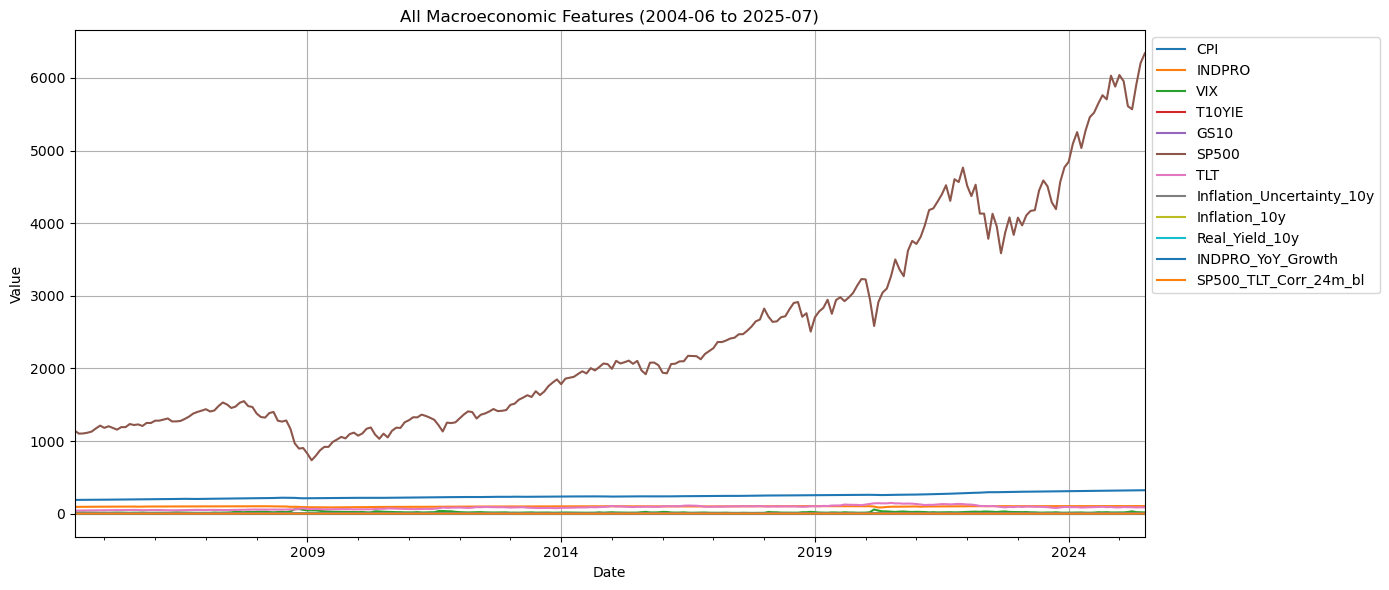

In [496]:
# Plot all columns
macro_final_bl_df.plot(figsize=(14, 6))
plt.title("All Macroeconomic Features (2004-06 to 2025-07)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

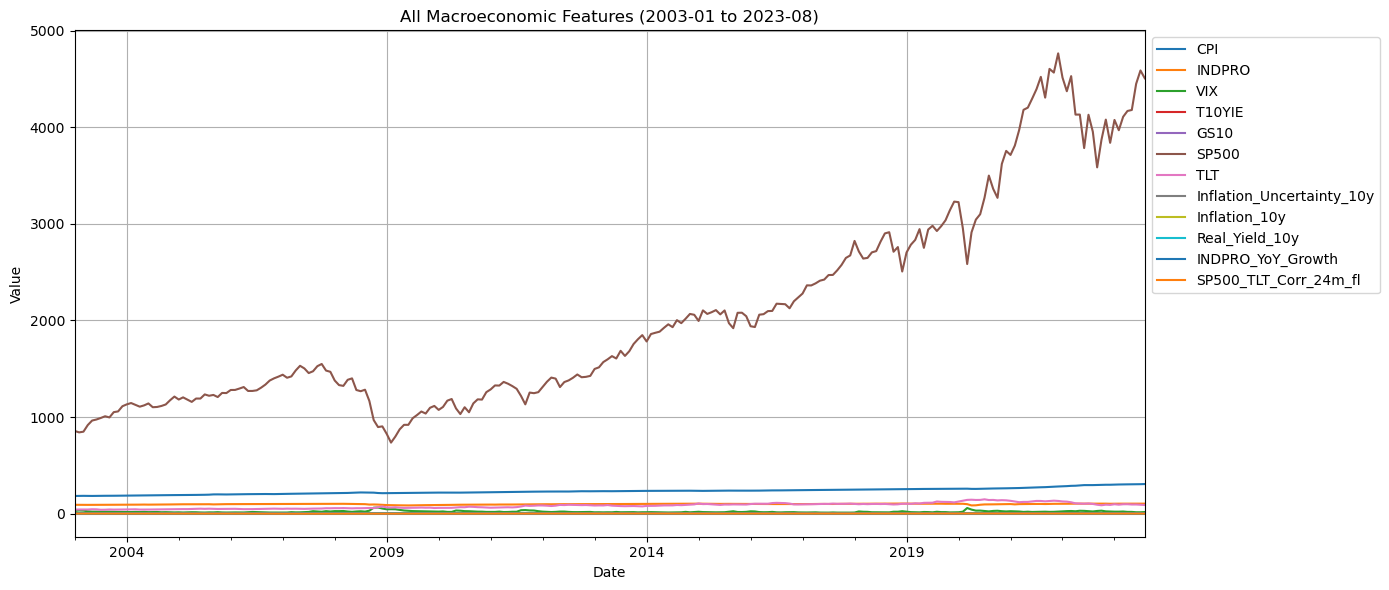

In [498]:
# Plot all columns
macro_final_fl_df.plot(figsize=(14, 6))
plt.title("All Macroeconomic Features (2003-01 to 2023-08)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

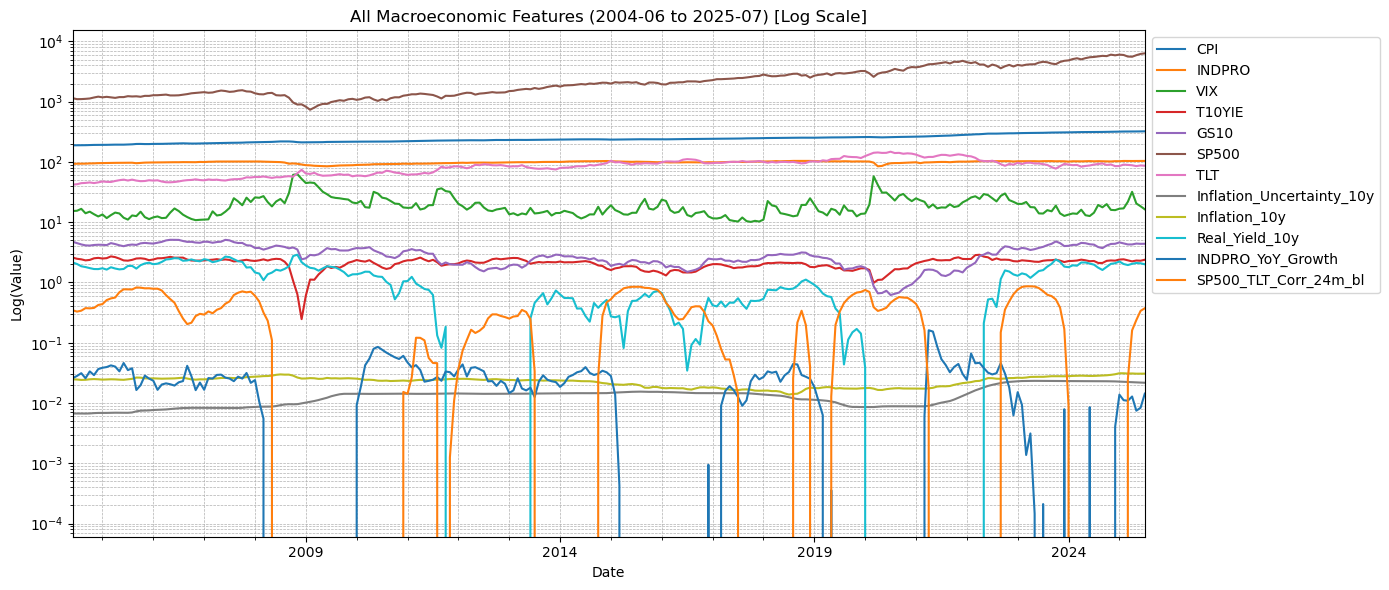

In [500]:
# Plot all columns with log scale
ax = macro_final_bl_df.plot(figsize=(14, 6))
plt.yscale('log')  # Apply log scale to y-axis

plt.title("All Macroeconomic Features (2004-06 to 2025-07) [Log Scale]")
plt.xlabel("Date")
plt.ylabel("Log(Value)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

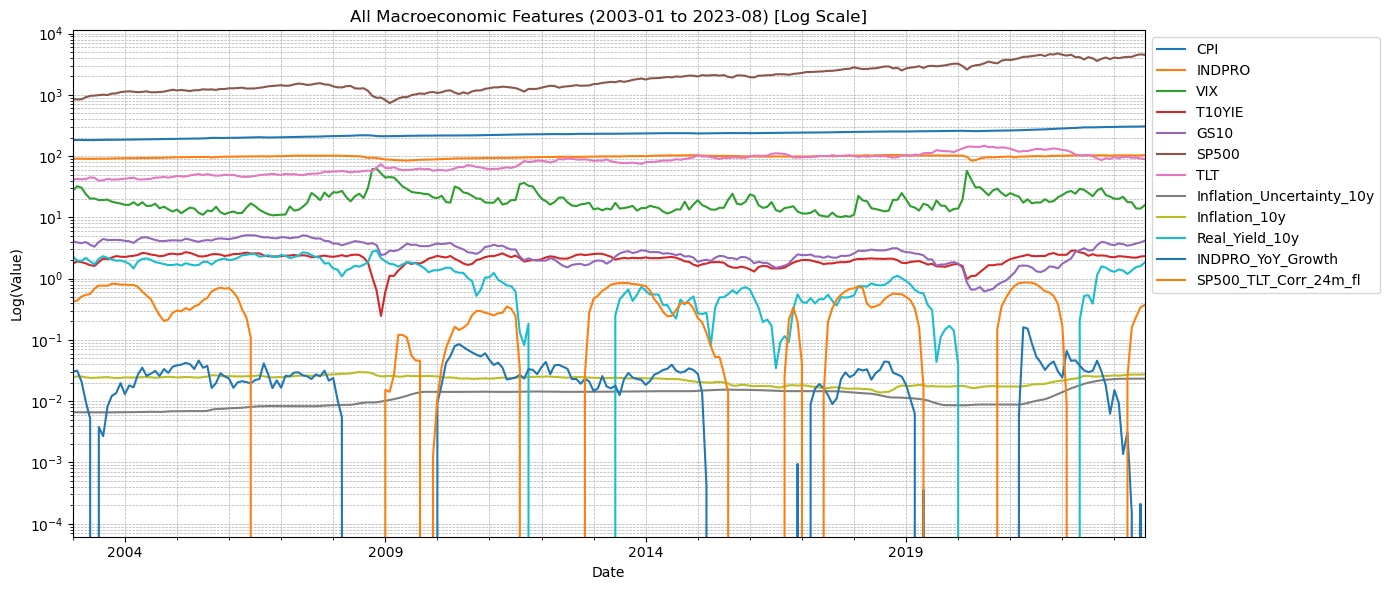

In [502]:
# Plot all columns with log scale
ax = macro_final_fl_df.plot(figsize=(14, 6))
plt.yscale('log')  # Apply log scale to y-axis

plt.title("All Macroeconomic Features (2003-01 to 2023-08) [Log Scale]")
plt.xlabel("Date")
plt.ylabel("Log(Value)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

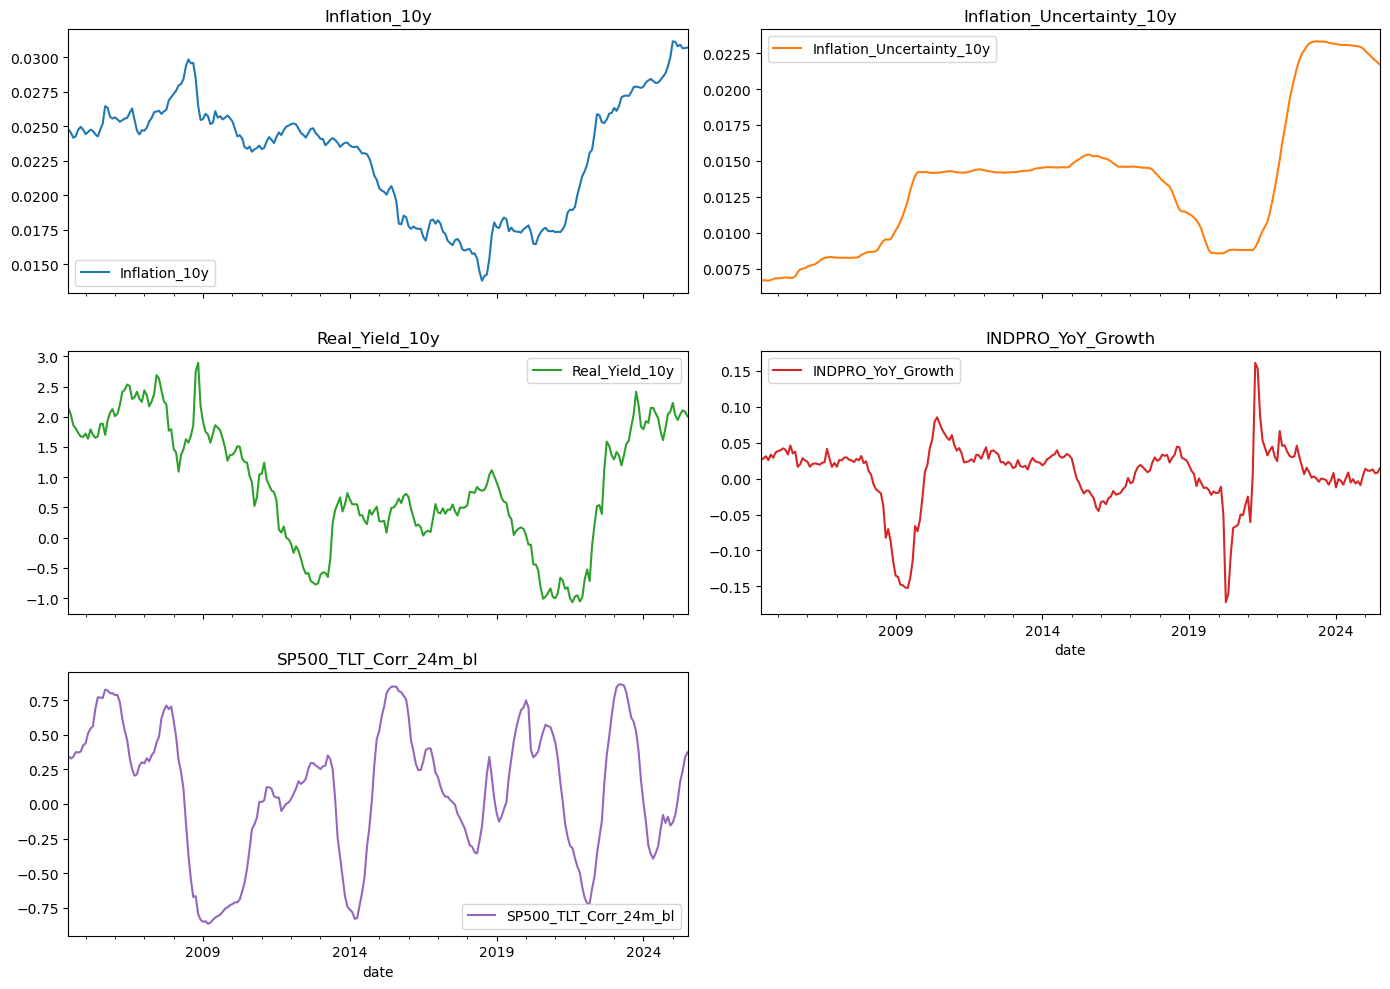

In [506]:
# Plot All Derived Features Only
derived_cols = ['Inflation_10y', 'Inflation_Uncertainty_10y', 'Real_Yield_10y', 
                'INDPRO_YoY_Growth', 'SP500_TLT_Corr_24m_bl']

macro_final_bl_df[derived_cols].plot(subplots=True, figsize=(14, 10), layout=(3, 2), title=derived_cols)
plt.tight_layout()
plt.show()

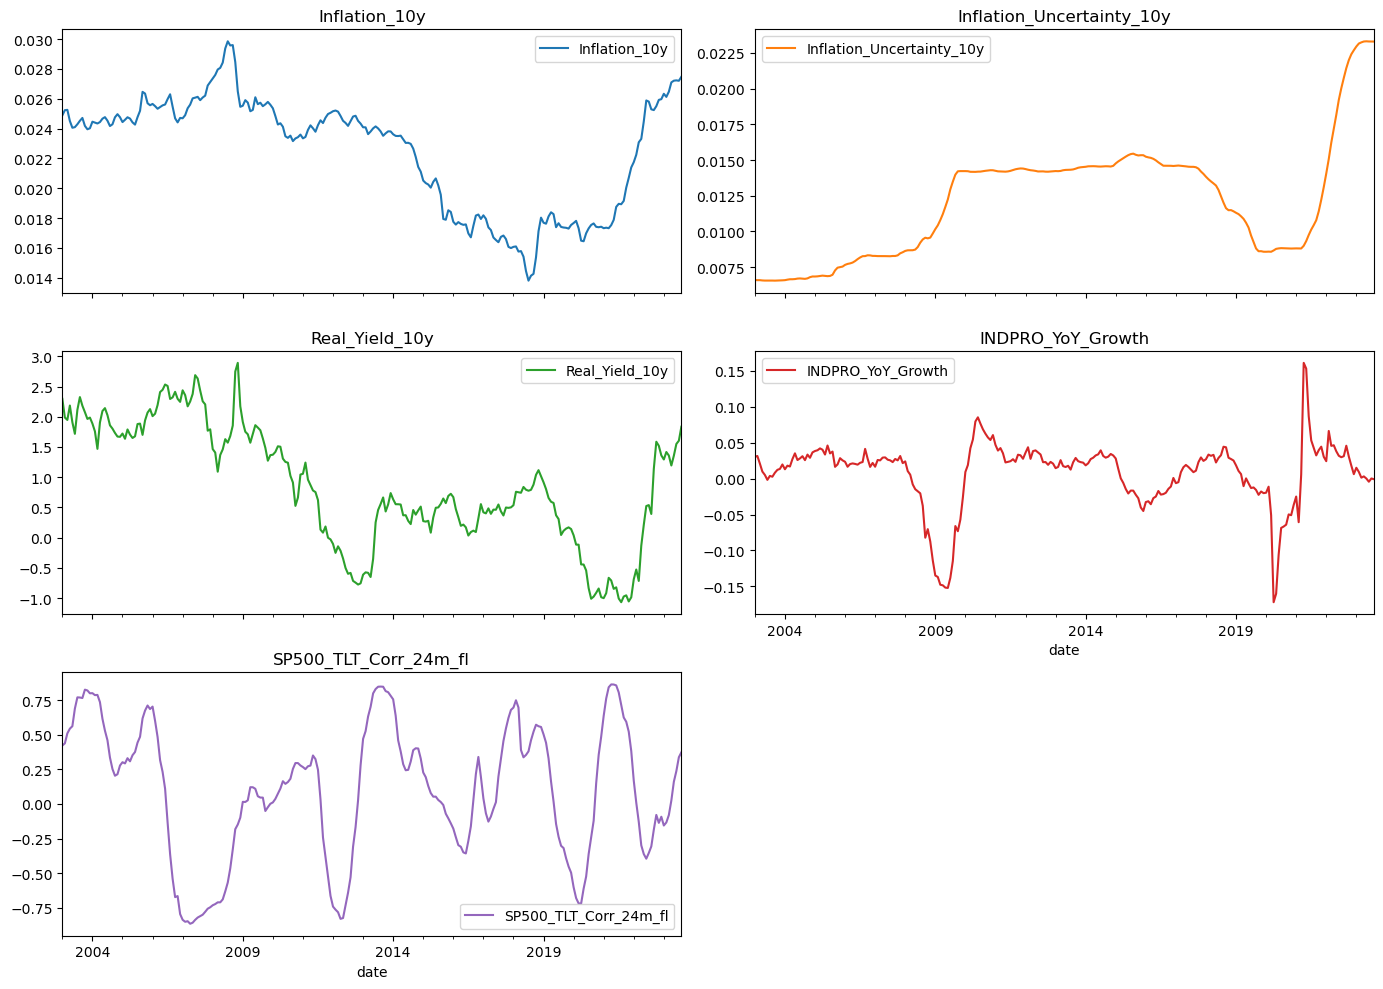

In [508]:
# Plot All Derived Features Only
derived_cols = ['Inflation_10y', 'Inflation_Uncertainty_10y', 'Real_Yield_10y', 
                'INDPRO_YoY_Growth', 'SP500_TLT_Corr_24m_fl']

macro_final_fl_df[derived_cols].plot(subplots=True, figsize=(14, 10), layout=(3, 2), title=derived_cols)
plt.tight_layout()
plt.show()

In [336]:
# macro_cleaned_path = os.path.join(macro_directory, "macro_full_df_clean.csv")

# macro_full_df_clean.to_csv(macro_cleaned_path)
# print(f"Saved cleaned macro data to: {macro_cleaned_path}")

Saved cleaned macro data to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/macro_full_df_clean.csv


In [510]:
# Define save paths
macro_bl_path = os.path.join(macro_directory, "macro_final_bl_df.csv")
macro_fl_path = os.path.join(macro_directory, "macro_final_fl_df.csv")

# Save dataframes
macro_final_bl_df.to_csv(macro_bl_path)
macro_final_fl_df.to_csv(macro_fl_path)

# Print confirmation
print(f"Saved backward-looking dataset to: {macro_bl_path}")
print(f"Saved forward-looking dataset to: {macro_fl_path}")

Saved backward-looking dataset to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/macro_final_bl_df.csv
Saved forward-looking dataset to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/macro_final_fl_df.csv
